In [1]:
import pandas as pd

# Define the path to your dataset
# Assuming togo-dapaong_qc.csv is in the root data/ directory
# Adjust the path if your file is located elsewhere relative to the notebook
file_path = '/home/y/Downloads/data/togo-dapaong_qc.csv'

# Load the dataset into a pandas DataFrame
try:
    df_tg = pd.read_csv(file_path) # Using df_tg for Togo
    print("Togo Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please check the file path and make sure 'togo-dapaong_qc.csv' is in the correct location.")

# Display the first few rows of the DataFrame
print("\nFirst 5 rows of the Togo dataset:")
print(df_tg.head())

# Display the column names and their data types
print("\nTogo Dataset Info:")
df_tg.info()

Togo Dataset loaded successfully!

First 5 rows of the Togo dataset:
          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-10-25 00:01 -1.3  0.0  0.0   0.0   0.0  24.8  94.5  0.9     1.1   
1  2021-10-25 00:02 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.1     1.6   
2  2021-10-25 00:03 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.2     1.4   
3  2021-10-25 00:04 -1.2  0.0  0.0   0.0   0.0  24.8  94.3  1.2     1.6   
4  2021-10-25 00:05 -1.2  0.0  0.0   0.0   0.0  24.8  94.0  1.3     1.6   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB  \
0      0.4  227.6      1.1  977         0            0.0   24.7   24.4   
1      0.4  229.3      0.7  977         0            0.0   24.7   24.4   
2      0.3  228.5      2.9  977         0            0.0   24.7   24.4   
3      0.3  229.1      4.6  977         0            0.0   24.7   24.4   
4      0.4  227.5      1.6  977         0            0.0   24.7   24.4   

   Comments  
0       NaN  
1      

In [2]:
# Perform df.describe() on all numeric columns
print("Summary Statistics for Togo Numeric Columns:")
print(df_tg.describe())

# Perform df.isna().sum() to get the count of missing values per column
print("\nMissing Value Count per Column for Togo:")
missing_values_tg = df_tg.isna().sum()
print(missing_values_tg)

# List any column with >5% nulls for Togo
print("\nTogo Columns with >5% Missing Values:")
total_rows_tg = len(df_tg)
for column, count in missing_values_tg.items():
    percentage = (count / total_rows_tg) * 100
    if percentage > 5:
        print(f"- {column}: {count} missing values ({percentage:.2f}%)")

Summary Statistics for Togo Numeric Columns:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      230.555040     151.258469     116.444352     226.144375   
std       322.532347     250.956962     156.520714     317.346938   
min       -12.700000       0.000000       0.000000       0.000000   
25%        -2.200000       0.000000       0.000000       0.000000   
50%         2.100000       0.000000       2.500000       4.400000   
75%       442.400000     246.400000     215.700000     422.525000   
max      1424.000000    1004.500000     805.700000    1380.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      219.568588      27.751788      55.013160       2.368093   
std       307.932510       4.758023      28.778732       1.462668   
min         0.000000      14.900000       3.300000       

In [3]:
import numpy as np
from scipy.stats import zscore
import pandas as pd # Ensure pandas is imported

# --- Outlier Detection (using Z-scores) ---

# Define the columns to check for outliers
outlier_cols_tg = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

print("Calculating Z-scores for outlier detection for Togo...")

# Calculate Z-scores for the specified columns
# We use np.abs() to get the absolute Z-score
# Ensure df_tg is accessible - if this is a standalone cell, you'd need to load data first.
# Assuming df_tg was loaded in a previous cell and that cell has been run.
z_scores_tg = df_tg[outlier_cols_tg].apply(zscore, nan_policy='omit') # 'omit' ignores potential NaNs

# Flag rows where the absolute Z-score is greater than 3 in any of the specified columns
# We create a boolean mask
outlier_mask_tg = (np.abs(z_scores_tg) > 3).any(axis=1)

# Add a new column to the DataFrame to flag potential outlier rows
df_tg['Potential_Outlier_Zscore'] = outlier_mask_tg

print(f"\nNumber of Togo rows potentially flagged as outliers based on Z-score (>3): {outlier_mask_tg.sum()}")
print("\nFirst 5 Togo rows with outlier flag:")
# Select columns to display, including the new flag
cols_to_display_tg = ['Timestamp'] + outlier_cols_tg + ['Potential_Outlier_Zscore']
print(df_tg[cols_to_display_tg].head())


# --- Basic Cleaning (Handling Missing Values) ---

# We identified that the 'Comments' column is 100% missing.
# It provides no information, so we will drop it.
print("\nHandling missing values for Togo...")
if 'Comments' in df_tg.columns:
    df_tg = df_tg.drop('Comments', axis=1)
    print("Dropped the 'Comments' column from Togo data due to 100% missing values.")
else:
    print("'Comments' column not found or already dropped in Togo data.")


print("\nCleaning steps completed for Togo.")
print("\nTogo Dataset Info after dropping 'Comments' column:")
df_tg.info() # Check info again to see 'Comments' is gone

Calculating Z-scores for outlier detection for Togo...

Number of Togo rows potentially flagged as outliers based on Z-score (>3): 9251

First 5 Togo rows with outlier flag:
          Timestamp  GHI  DNI  DHI  ModA  ModB   WS  WSgust  \
0  2021-10-25 00:01 -1.3  0.0  0.0   0.0   0.0  0.9     1.1   
1  2021-10-25 00:02 -1.3  0.0  0.0   0.0   0.0  1.1     1.6   
2  2021-10-25 00:03 -1.3  0.0  0.0   0.0   0.0  1.2     1.4   
3  2021-10-25 00:04 -1.2  0.0  0.0   0.0   0.0  1.2     1.6   
4  2021-10-25 00:05 -1.2  0.0  0.0   0.0   0.0  1.3     1.6   

   Potential_Outlier_Zscore  
0                     False  
1                     False  
2                     False  
3                     False  
4                     False  

Handling missing values for Togo...
Dropped the 'Comments' column from Togo data due to 100% missing values.

Cleaning steps completed for Togo.

Togo Dataset Info after dropping 'Comments' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 

In [4]:
import os
import pandas as pd # Ensure pandas is imported

# Define the path for the output directory and file
output_dir_tg = '../data/'
output_file_path_tg = os.path.join(output_dir_tg, 'togo_clean.csv')

# Ensure the output directory exists
print(f"Ensuring directory '{output_dir_tg}' exists for Togo...")
os.makedirs(output_dir_tg, exist_ok=True)
print(f"Directory '{output_dir_tg}' checked/created for Togo.")

# Export the cleaned DataFrame to a CSV file
# index=False prevents pandas from writing the DataFrame index as a column in the CSV
# Ensure df_tg is accessible - if this is a standalone cell, you'd need to load data first.
# Assuming df_tg was loaded and cleaned in previous cells and those cells have been run.
print(f"\nExporting cleaned Togo data to '{output_file_path_tg}'...")
df_tg.to_csv(output_file_path_tg, index=False)
print("Cleaned Togo data exported successfully!")

Ensuring directory '../data/' exists for Togo...
Directory '../data/' checked/created for Togo.

Exporting cleaned Togo data to '../data/togo_clean.csv'...
Cleaned Togo data exported successfully!


Converting 'Timestamp' column to datetime for Togo...
'Timestamp' column converted to datetime for Togo.

Generating Time Series Plots for GHI, DNI, DHI, and Tamb for Togo...


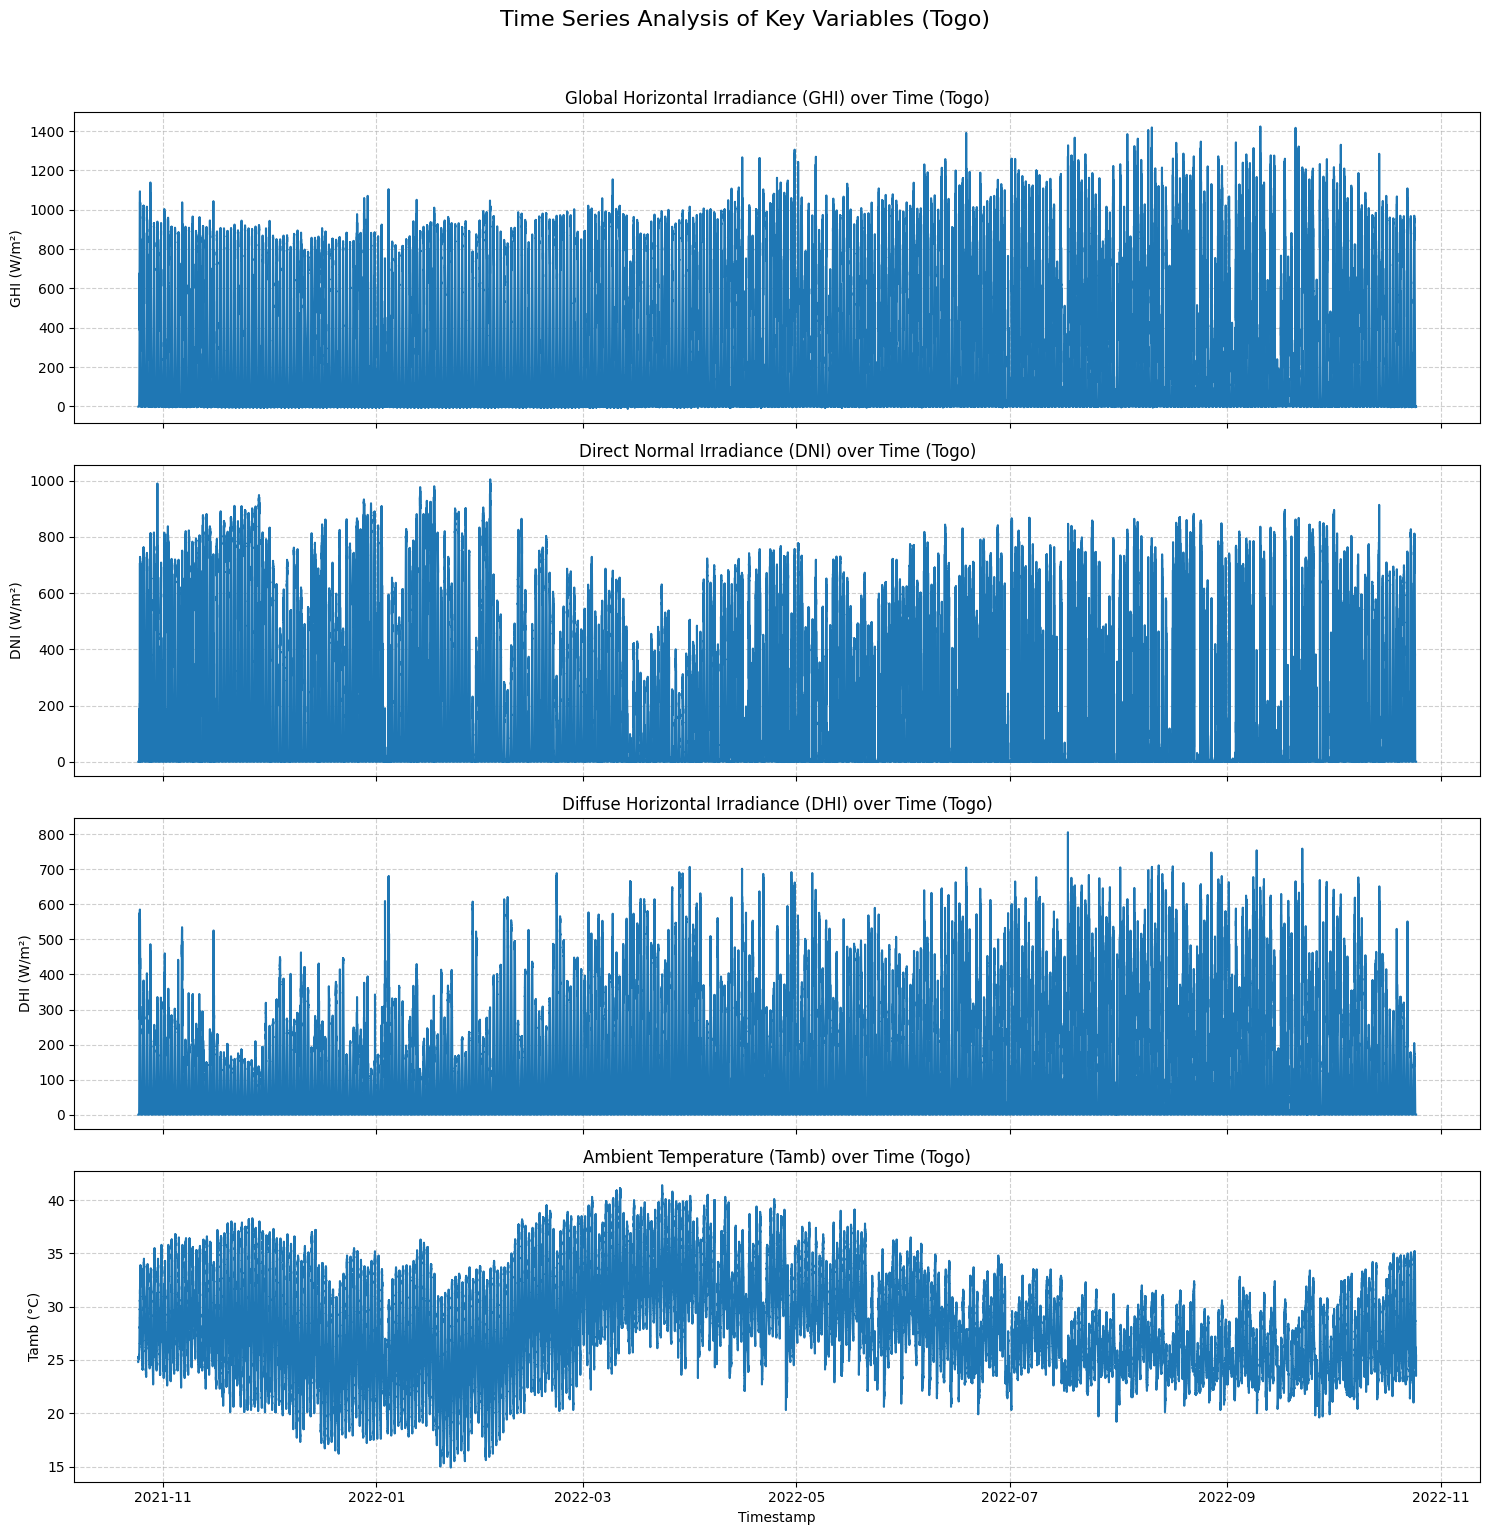


Time Series Plots generated for Togo.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# --- Prepare Timestamp Column ---

print("Converting 'Timestamp' column to datetime for Togo...")
# Convert the 'Timestamp' column to datetime objects
# Ensure df_tg is accessible - if this is a standalone cell, you'd need to load data first.
# Assuming df_tg was loaded in a previous cell and that cell has been run.
df_tg['Timestamp'] = pd.to_datetime(df_tg['Timestamp'], errors='coerce')
print("'Timestamp' column converted to datetime for Togo.")


# --- Time Series Analysis Plots ---

print("\nGenerating Time Series Plots for GHI, DNI, DHI, and Tamb for Togo...")

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 15), sharex=True)
fig.suptitle('Time Series Analysis of Key Variables (Togo)', y=1.02, fontsize=16)

# Plot GHI vs Timestamp
sns.lineplot(ax=axes[0], x=df_tg['Timestamp'], y=df_tg['GHI'])
axes[0].set_title('Global Horizontal Irradiance (GHI) over Time (Togo)')
axes[0].set_ylabel('GHI (W/m²)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot DNI vs Timestamp
sns.lineplot(ax=axes[1], x=df_tg['Timestamp'], y=df_tg['DNI'])
axes[1].set_title('Direct Normal Irradiance (DNI) over Time (Togo)')
axes[1].set_ylabel('DNI (W/m²)')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot DHI vs Timestamp
sns.lineplot(ax=axes[2], x=df_tg['Timestamp'], y=df_tg['DHI'])
axes[2].set_title('Diffuse Horizontal Irradiance (DHI) over Time (Togo)')
axes[2].set_ylabel('DHI (W/m²)')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Plot Tamb vs Timestamp
sns.lineplot(ax=axes[3], x=df_tg['Timestamp'], y=df_tg['Tamb'])
axes[3].set_title('Ambient Temperature (Tamb) over Time (Togo)')
axes[3].set_ylabel('Tamb (°C)')
axes[3].set_xlabel('Timestamp') # Only the bottom plot needs the x-label
axes[3].grid(True, linestyle='--', alpha=0.6)


# Improve layout and display the plots
plt.tight_layout()
plt.show()

print("\nTime Series Plots generated for Togo.")

Analyzing Cleaning Impact on average ModA and ModB for Togo...

Average ModA and ModB grouped by Cleaning flag (0: No Cleaning, 1: Cleaning) for Togo:
                ModA        ModB
Cleaning                        
0         225.979064  219.401351
1         535.186477  532.211744


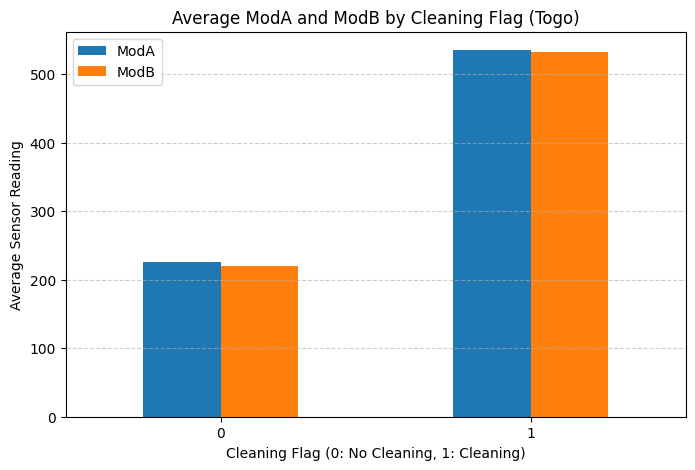


Cleaning Impact analysis completed for Togo.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# --- Cleaning Impact Analysis ---

print("Analyzing Cleaning Impact on average ModA and ModB for Togo...")

# Ensure df_tg is accessible - if this is a standalone cell, you'd need to load data first.
# Assuming df_tg was loaded and cleaned in previous cells and those cells have been run.

# Group the DataFrame by the 'Cleaning' column and calculate the mean of ModA and ModB
cleaning_impact_tg = df_tg.groupby('Cleaning')[['ModA', 'ModB']].mean()

print("\nAverage ModA and ModB grouped by Cleaning flag (0: No Cleaning, 1: Cleaning) for Togo:")
print(cleaning_impact_tg)

# Plot the cleaning impact
cleaning_impact_tg.plot(kind='bar', figsize=(8, 5))
plt.title('Average ModA and ModB by Cleaning Flag (Togo)')
plt.xlabel('Cleaning Flag (0: No Cleaning, 1: Cleaning)')
plt.ylabel('Average Sensor Reading')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("\nCleaning Impact analysis completed for Togo.")

Generating Correlation Heatmap for Togo...


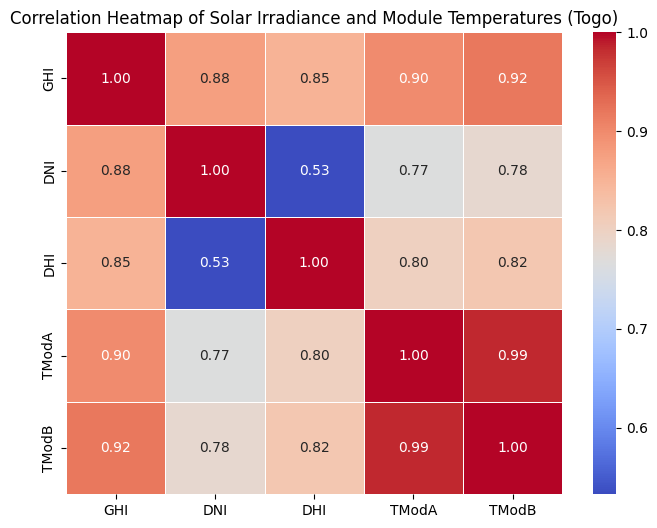


Correlation Heatmap generated for Togo.

Generating Scatter Plots for Togo...


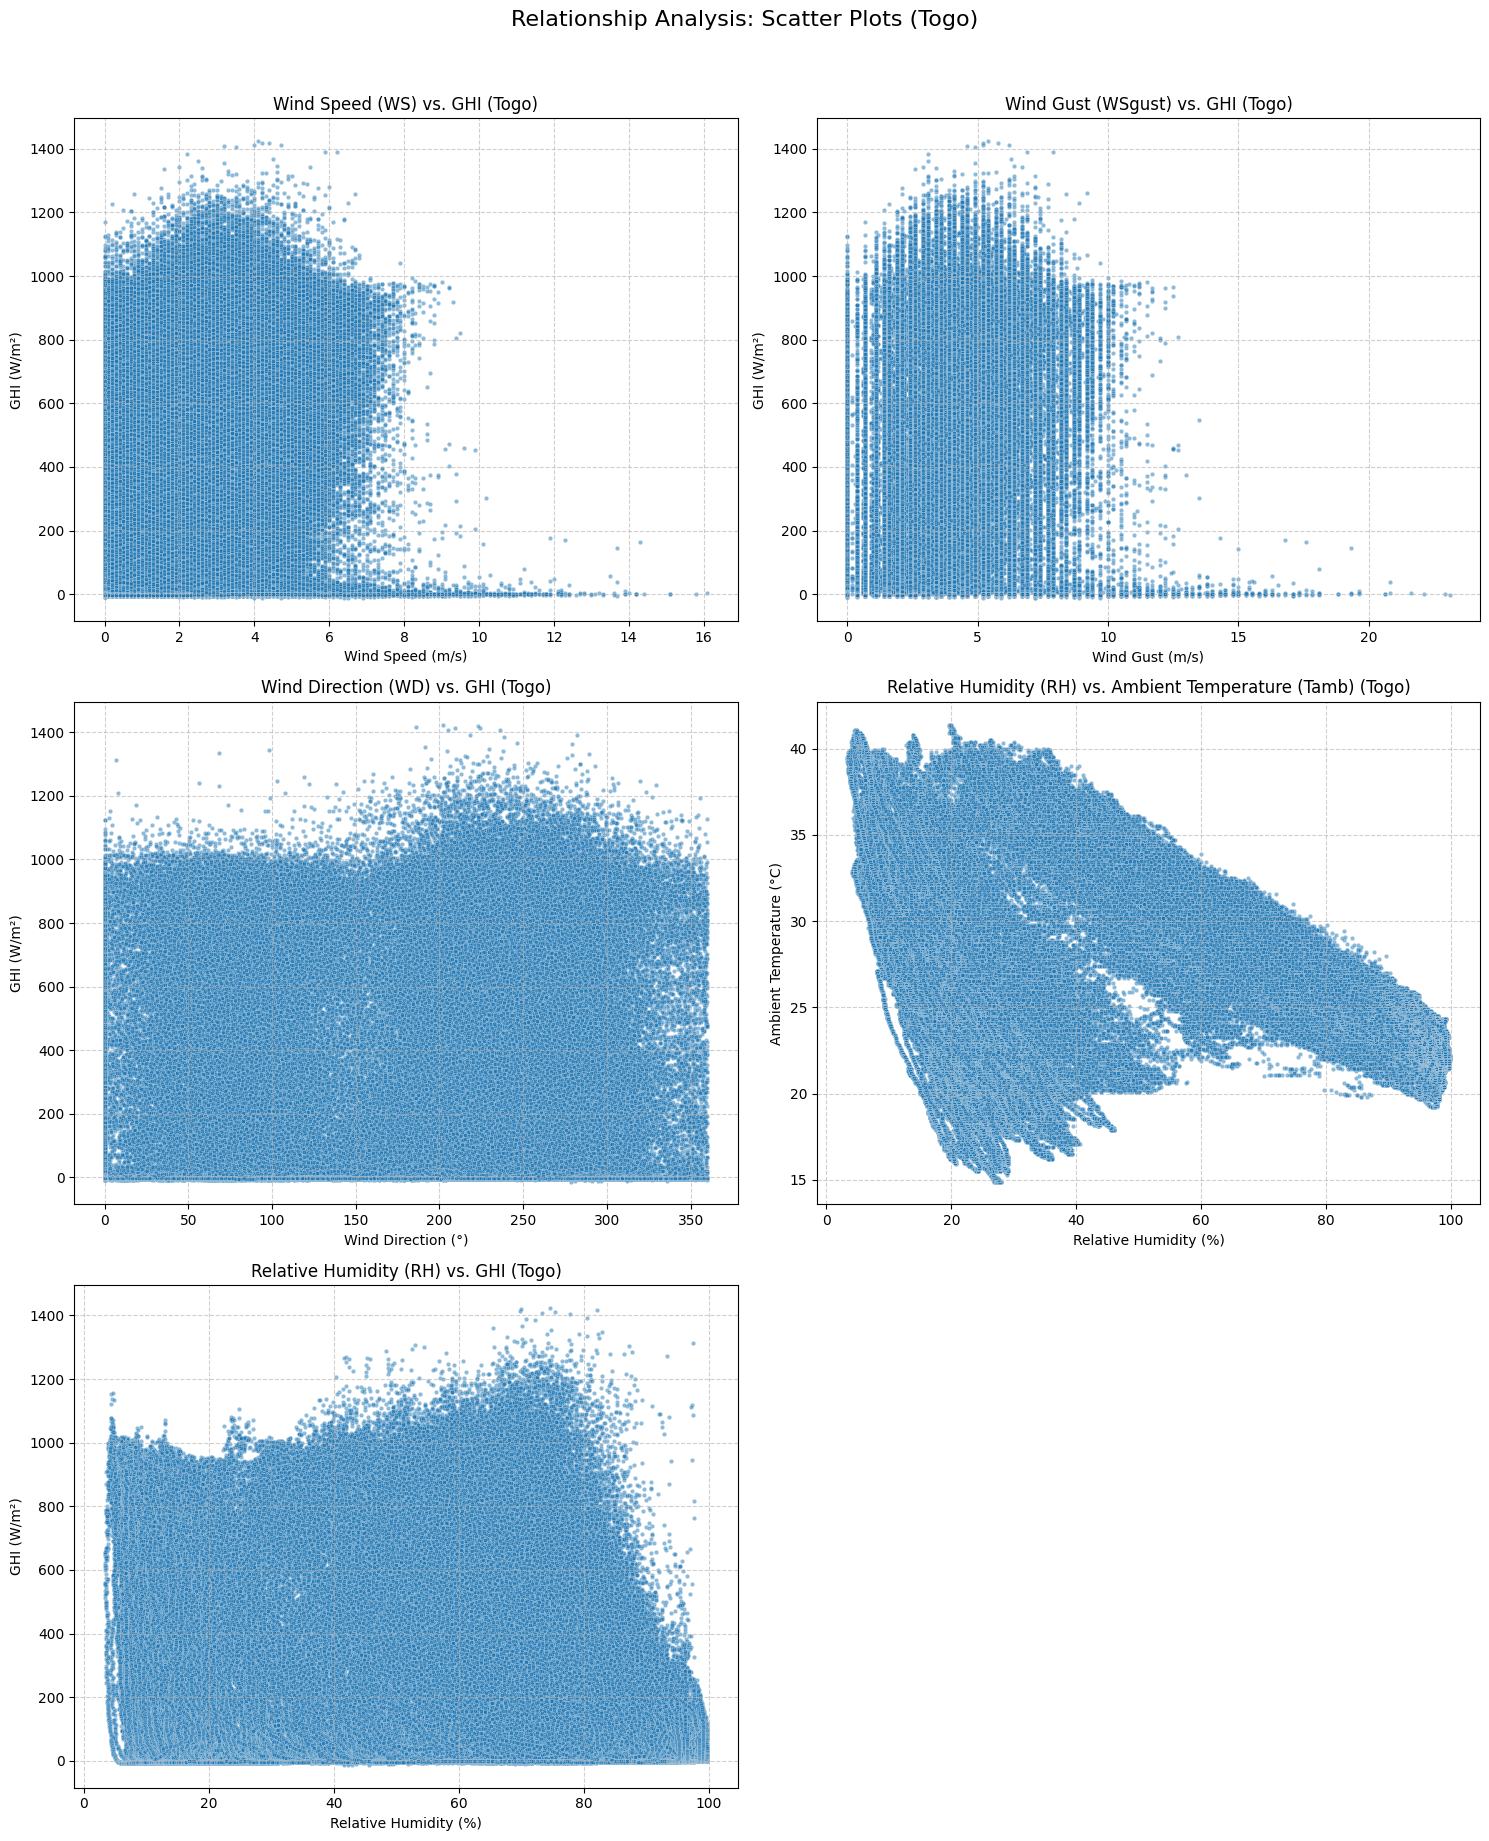


Scatter Plots generated for Togo.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# --- Correlation Analysis (Heatmap) ---

print("Generating Correlation Heatmap for Togo...")

# Define the columns for the correlation heatmap
heatmap_cols_tg = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']

# Ensure df_tg is accessible
# Assuming df_tg was loaded and cleaned in previous cells and those cells have been run.

# Calculate the correlation matrix
correlation_matrix_tg = df_tg[heatmap_cols_tg].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_tg, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Solar Irradiance and Module Temperatures (Togo)')
plt.show()

print("\nCorrelation Heatmap generated for Togo.")

# --- Relationship Analysis (Scatter Plots) ---

print("\nGenerating Scatter Plots for Togo...")

# Create a figure and a set of subplots for scatter plots
# We'll have 2 columns and 3 rows of plots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
fig.suptitle('Relationship Analysis: Scatter Plots (Togo)', y=1.02, fontsize=16)

# Scatter plot: WS vs GHI
sns.scatterplot(ax=axes[0, 0], data=df_tg, x='WS', y='GHI', alpha=0.5, s=10) # s is marker size
axes[0, 0].set_title('Wind Speed (WS) vs. GHI (Togo)')
axes[0, 0].set_xlabel('Wind Speed (m/s)')
axes[0, 0].set_ylabel('GHI (W/m²)')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: WSgust vs GHI
sns.scatterplot(ax=axes[0, 1], data=df_tg, x='WSgust', y='GHI', alpha=0.5, s=10)
axes[0, 1].set_title('Wind Gust (WSgust) vs. GHI (Togo)')
axes[0, 1].set_xlabel('Wind Gust (m/s)')
axes[0, 1].set_ylabel('GHI (W/m²)')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: WD vs GHI
sns.scatterplot(ax=axes[1, 0], data=df_tg, x='WD', y='GHI', alpha=0.5, s=10)
axes[1, 0].set_title('Wind Direction (WD) vs. GHI (Togo)')
axes[1, 0].set_xlabel('Wind Direction (°)')
axes[1, 0].set_ylabel('GHI (W/m²)')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: RH vs Tamb
sns.scatterplot(ax=axes[1, 1], data=df_tg, x='RH', y='Tamb', alpha=0.5, s=10)
axes[1, 1].set_title('Relative Humidity (RH) vs. Ambient Temperature (Tamb) (Togo)')
axes[1, 1].set_xlabel('Relative Humidity (%)')
axes[1, 1].set_ylabel('Ambient Temperature (°C)')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: RH vs GHI
sns.scatterplot(ax=axes[2, 0], data=df_tg, x='RH', y='GHI', alpha=0.5, s=10)
axes[2, 0].set_title('Relative Humidity (RH) vs. GHI (Togo)')
axes[2, 0].set_xlabel('Relative Humidity (%)')
axes[2, 0].set_ylabel('GHI (W/m²)')
axes[2, 0].grid(True, linestyle='--', alpha=0.6)

# Hide the unused subplot
fig.delaxes(axes[2, 1])

# Improve layout and display the plots
plt.tight_layout()
plt.show()

print("\nScatter Plots generated for Togo.")

Generating Histograms for GHI and WS for Togo...


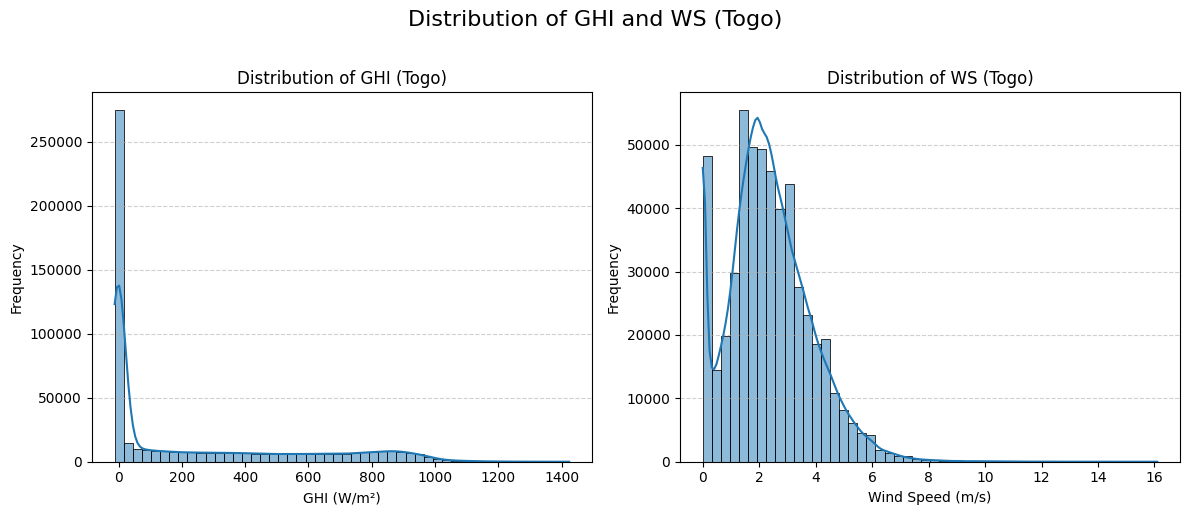


Histograms generated for Togo.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported
import numpy as np # Ensure numpy is imported

# --- Distribution Analysis (Histograms) ---

print("Generating Histograms for GHI and WS for Togo...")

# Ensure df_tg is accessible
# Assuming df_tg was loaded and cleaned in previous cells and those cells have been run.

# Create a figure and a set of subplots for histograms
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
fig.suptitle('Distribution of GHI and WS (Togo)', y=1.02, fontsize=16)

# Histogram for GHI
sns.histplot(ax=axes[0], data=df_tg, x='GHI', kde=True, bins=50) # kde=True adds a density curve
axes[0].set_title('Distribution of GHI (Togo)')
axes[0].set_xlabel('GHI (W/m²)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Histogram for WS
sns.histplot(ax=axes[1], data=df_tg, x='WS', kde=True, bins=50)
axes[1].set_title('Distribution of WS (Togo)')
axes[1].set_xlabel('Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\nHistograms generated for Togo.")


Generating Wind Rose Plot for Togo...


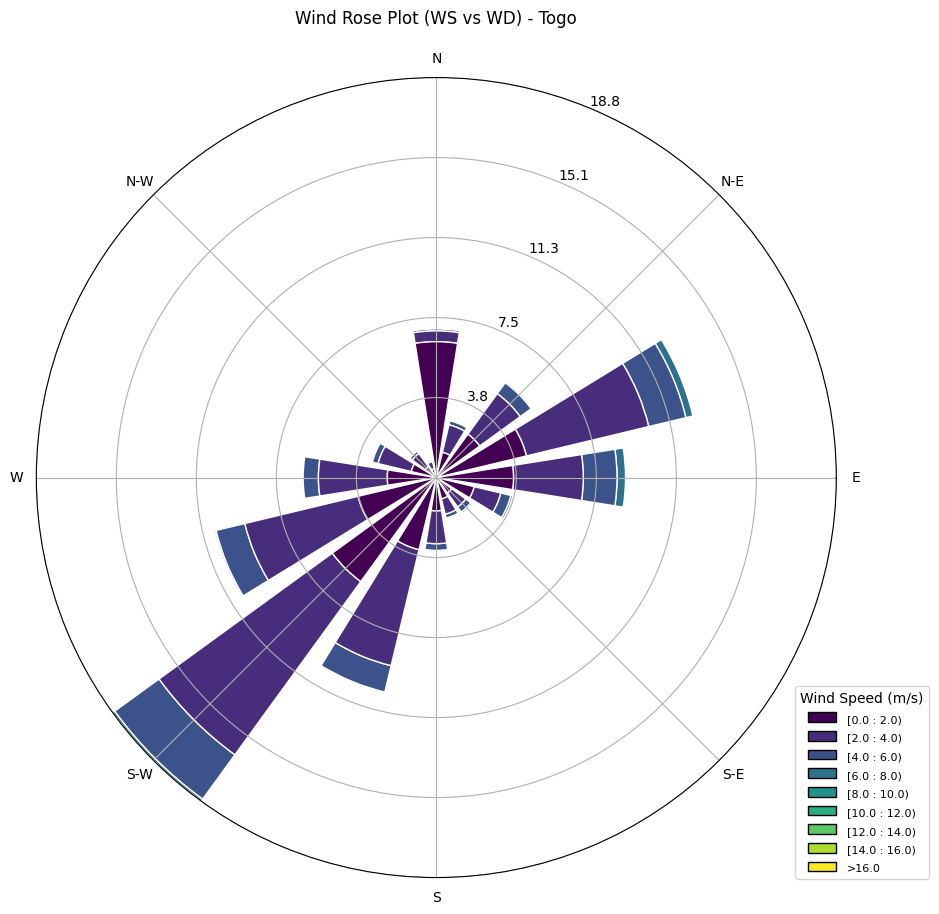

Wind Rose Plot generated for Togo.


In [9]:
# --- Wind Analysis (Wind Rose) ---

import matplotlib.pyplot as plt # Import matplotlib's plotting module
import matplotlib.cm as cm # Import colormap
import numpy as np # numpy is used implicitly by windrose and often needed alongside it
import pandas as pd # Ensure pandas is imported

print("\nGenerating Wind Rose Plot for Togo...")

try:
    from windrose import WindroseAxes

    # Create a new figure
    fig = plt.figure(figsize=(10, 10))
    # Create a WindroseAxes instance
    ax = WindroseAxes.from_ax(fig=fig, rect=[0.1, 0.1, 0.8, 0.8])

    # Plot the wind rose
    # ws is wind speed, wd is wind direction
    # Ensure df_tg is accessible
    # Assuming df_tg was loaded and cleaned in previous cells and those cells have been run.
    ax.bar(df_tg['WD'], df_tg['WS'], normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, df_tg['WS'].max() + 1, 2), cmap=cm.viridis)

    # Set title
    ax.set_title('Wind Rose Plot (WS vs WD) - Togo', pad=20)

    # Add legend
    ax.set_legend(title="Wind Speed (m/s)", loc="lower left", bbox_to_anchor=(0.95, 0)) # Position legend outside plot

    plt.show()
    print("Wind Rose Plot generated for Togo.")

except ImportError:
    print("The 'windrose' library is not installed in your current environment.")
    print("Please install it using: pip install windrose in your active terminal or VS Code integrated terminal.")
    print("Skipping Wind Rose plot generation for Togo.")
except NameError:
    print("Error: DataFrame 'df_tg' not found. Please run the data loading cell (Step 4 for Togo) first.")
except Exception as e:
    print(f"An error occurred while generating the Wind Rose plot for Togo: {e}")


Generating Bubble Chart (GHI vs Tamb, Bubble Size = RH) for Togo...


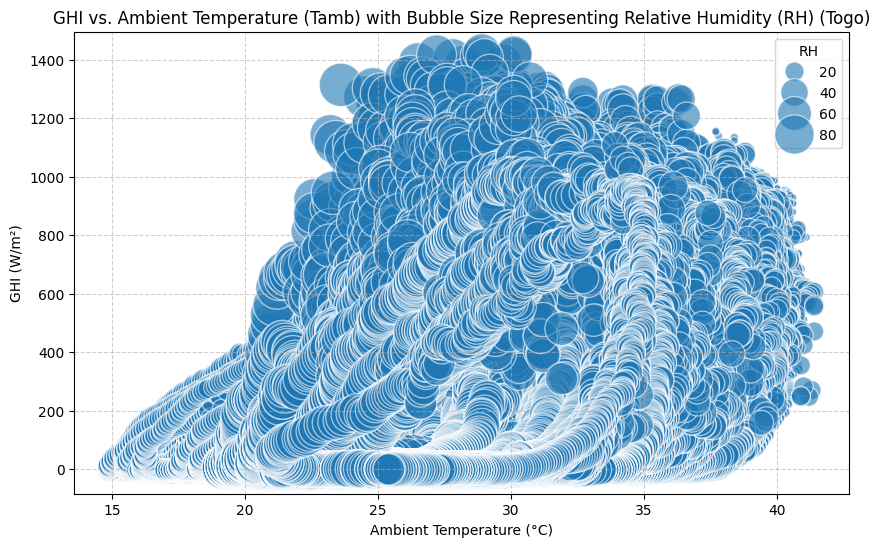


Bubble Chart generated for Togo.


In [10]:
# --- Bubble Chart Analysis ---

import matplotlib.pyplot as plt # Import matplotlib's plotting module
import seaborn as sns # Import seaborn for enhanced visualizations
import pandas as pd # Ensure pandas is imported

print("\nGenerating Bubble Chart (GHI vs Tamb, Bubble Size = RH) for Togo...")

try:
    # Create the bubble chart
    # Ensure df_tg is accessible
    # Assuming df_tg was loaded and cleaned in previous cells and those cells have been run.
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_tg, x='Tamb', y='GHI', size='RH', alpha=0.6, sizes=(20, 1000)) # sizes controls the range of bubble sizes

    plt.title('GHI vs. Ambient Temperature (Tamb) with Bubble Size Representing Relative Humidity (RH) (Togo)')
    plt.xlabel('Ambient Temperature (°C)')
    plt.ylabel('GHI (W/m²)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    print("\nBubble Chart generated for Togo.")

    # --- Optional: Bubble Chart with Bubble Size = BP ---
    # If you wanted to use Barometric Pressure (BP) for bubble size instead, you would change the 'size' parameter:
    # print("\nGenerating Bubble Chart (GHI vs Tamb, Bubble Size = BP) for Togo...")
    # plt.figure(figsize=(10, 6))
    # sns.scatterplot(data=df_tg, x='Tamb', y='GHI', size='BP', alpha=0.6, sizes=(20, 1000))
    # plt.title('GHI vs. Ambient Temperature (Tamb) with Bubble Size Representing Barometric Pressure (BP) (Togo)')
    # plt.xlabel('Ambient Temperature (°C)')
    # plt.ylabel('GHI (W/m²)')
    # plt.grid(True, linestyle='--', alpha=0.6)
    # plt.show()
    # print("\nBubble Chart (BP) generated for Togo.")

except NameError:
     print("Error: DataFrame 'df_tg' not found. Please run the data loading cell (Step 4 for Togo) first.")
except Exception as e:
    print(f"An error occurred while generating the Bubble Chart for Togo: {e}")